<a href="https://colab.research.google.com/github/shreyashbhat1111/ML_Intern/blob/main/ML_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [5]:
# Check target column
print("Target values:")
print(df['num'].value_counts())

Target values:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [6]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [7]:
# Check target values
print("Target values:")
print(df['num'].value_counts().sort_index())

Target values:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [8]:
# Convert target into binary classification
# 0 = No Heart Disease
# 1,2,3,4 = Heart Disease

df['target'] = (df['num'] > 0).astype(int)

print("Binary target distribution:")
print(df['target'].value_counts())

Binary target distribution:
target
1    509
0    411
Name: count, dtype: int64


In [9]:
# Remove unnecessary columns
df_model = df.drop(['id', 'dataset', 'num'], axis=1)

print("Columns after removing unnecessary columns:")
print(df_model.columns.tolist())

Columns after removing unnecessary columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [10]:
# Convert categorical columns into numerical columns
df_model = pd.get_dummies(df_model, drop_first=True)

print("New dataset shape:", df_model.shape)
df_model.head()

New dataset shape: (920, 19)


,age,trestbps,chol,thalch,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False


In [11]:
# Check missing values after encoding
print("Missing values:")
print(df_model.isnull().sum())

Missing values:
age                           0
trestbps                     59
chol                         30
thalch                       55
oldpeak                      62
ca                          611
target                        0
sex_Male                      0
cp_atypical angina            0
cp_non-anginal                0
cp_typical angina             0
fbs_True                      0
restecg_normal                0
restecg_st-t abnormality      0
exang_True                    0
slope_flat                    0
slope_upsloping               0
thal_normal                   0
thal_reversable defect        0
dtype: int64


In [12]:
# Fill missing numerical values with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

print("Total missing values after cleaning:")
print(df_model.isnull().sum().sum())

Total missing values after cleaning:
0


       HEART DISEASE PREDICTION - WEEK 4

1. DATASET INFORMATION
----------------------------------------
Dataset Shape: (920, 17)

Original Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target']

2. DATA CLEANING
----------------------------------------
Missing values before processing:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Target Distribution:
target
1    509
0    411
Name: count, dtype: int64

Target Meaning:
0 = No Heart Disease
1 = Heart Disease

3. AFTER CATEGORICAL ENCODING
----------------------------------------
Feature Shape: (920, 18)
Total Missing Values After Cleaning: 0

4. TRAIN-TEST SPLIT
----------------------------------------
Training Samples: 736
Testing Samples : 184

Fe

<Figure size 600x500 with 0 Axes>

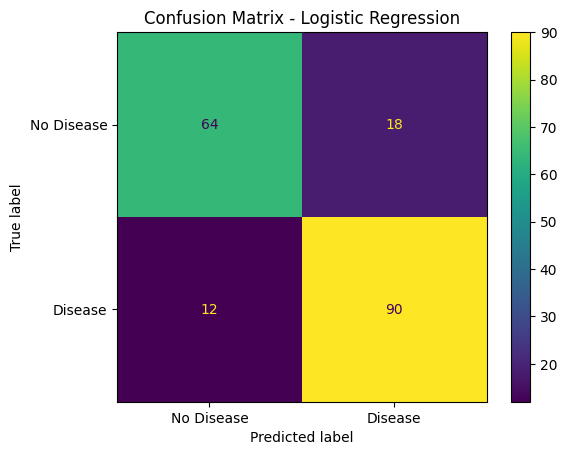


             DECISION TREE
Accuracy : 0.7935
Precision: 0.8077
Recall   : 0.8235
ROC-AUC  : 0.8736

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.78      0.76      0.77        82
     Disease       0.81      0.82      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



<Figure size 600x500 with 0 Axes>

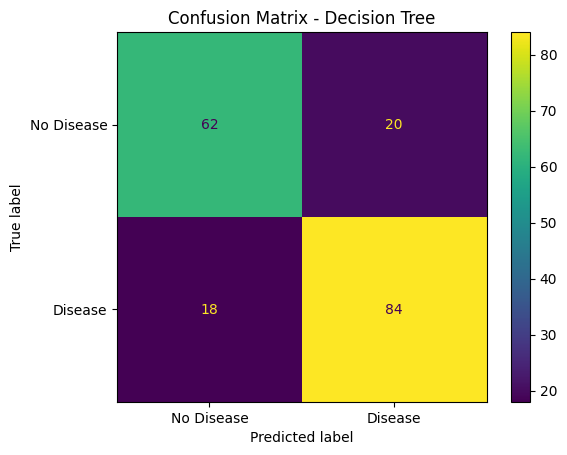


             MODEL COMPARISON
              Model  Accuracy  Precision  Recall  ROC-AUC
Logistic Regression    0.8370     0.8333  0.8824   0.9029
      Decision Tree    0.7935     0.8077  0.8235   0.8736


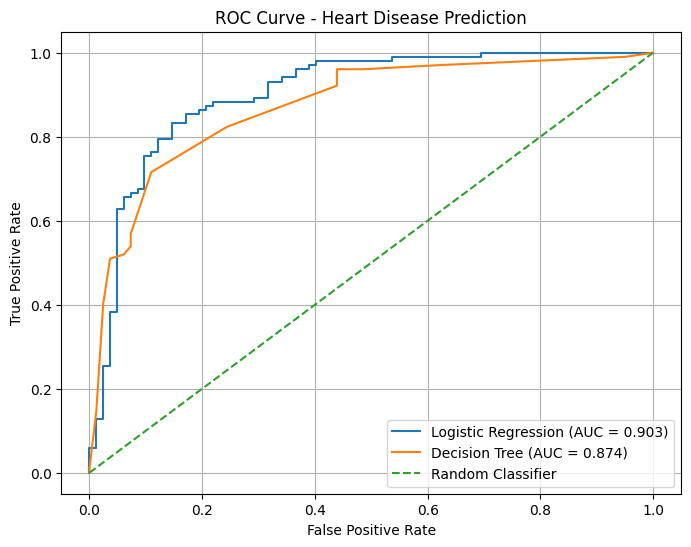


             SAMPLE PREDICTION
Model Prediction: Lower predicted likelihood of heart disease
Predicted Probability: 43.69 %

             PROJECT COMPLETED

The Heart Disease Prediction project has completed the required
machine learning workflow:

✓ Data Cleaning
✓ Categorical Data Encoding
✓ Missing Value Handling
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression
✓ Decision Tree
✓ Accuracy Evaluation
✓ Precision Evaluation
✓ Recall Evaluation
✓ Confusion Matrix Visualization
✓ ROC Curve Visualization
✓ ROC-AUC Evaluation
✓ Sample Prediction

Note:
This is an educational machine learning project. Model predictions
are not medical diagnoses and should not replace professional
medical evaluation.



In [13]:
# ============================================================
# WEEK 4 - MAJOR PROJECT
# HEART DISEASE PREDICTION
# ============================================================

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("=" * 60)
print("       HEART DISEASE PREDICTION - WEEK 4")
print("=" * 60)


# -------------------- 2. DATASET INFORMATION --------------------

print("\n1. DATASET INFORMATION")
print("-" * 40)

print("Dataset Shape:", df.shape)
print("\nOriginal Columns:")
print(df.columns.tolist())


# -------------------- 3. DATA CLEANING --------------------

print("\n2. DATA CLEANING")
print("-" * 40)

# Create a copy so original dataset remains unchanged
data = df.copy()

# Remove completely empty rows
data = data.dropna(how='all')

# Convert target into binary classification
# num = 0  -> No Heart Disease
# num > 0  -> Heart Disease

data['target'] = (pd.to_numeric(data['num'], errors='coerce') > 0).astype(int)

# Remove unnecessary columns
columns_to_remove = ['id', 'dataset', 'num']

for col in columns_to_remove:
    if col in data.columns:
        data = data.drop(columns=col)

print("Missing values before processing:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data['target'].value_counts())

print("\nTarget Meaning:")
print("0 = No Heart Disease")
print("1 = Heart Disease")


# -------------------- 4. SEPARATE FEATURES AND TARGET --------------------

X = data.drop('target', axis=1)
y = data['target']

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True, dtype=float)

print("\n3. AFTER CATEGORICAL ENCODING")
print("-" * 40)
print("Feature Shape:", X.shape)


# -------------------- 5. HANDLE MISSING VALUES --------------------

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values using median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Total Missing Values After Cleaning:", X.isnull().sum().sum())


# -------------------- 6. TRAIN-TEST SPLIT --------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n4. TRAIN-TEST SPLIT")
print("-" * 40)
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# -------------------- 7. FEATURE SCALING --------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed successfully.")


# ============================================================
# 8. LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 60)
print("       LOGISTIC REGRESSION")
print("=" * 60)

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("ROC-AUC  :", round(auc_lr, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['No Disease', 'Disease'],
    zero_division=0
))


# -------------------- 9. LOGISTIC REGRESSION CONFUSION MATRIX --------------------

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['No Disease', 'Disease']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# ============================================================
# 10. DECISION TREE
# ============================================================

print("\n" + "=" * 60)
print("             DECISION TREE")
print("=" * 60)

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, zero_division=0)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("ROC-AUC  :", round(auc_dt, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=['No Disease', 'Disease'],
    zero_division=0
))


# -------------------- 11. DECISION TREE CONFUSION MATRIX --------------------

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['No Disease', 'Disease']
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()


# ============================================================
# 12. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("             MODEL COMPARISON")
print("=" * 60)

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt
    ],
    'Precision': [
        precision_lr,
        precision_dt
    ],
    'Recall': [
        recall_lr,
        recall_dt
    ],
    'ROC-AUC': [
        auc_lr,
        auc_dt
    ]
})

print(results.round(4).to_string(index=False))


# ============================================================
# 13. ROC CURVE
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Heart Disease Prediction')
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 14. SAMPLE PREDICTION
# ============================================================

print("\n" + "=" * 60)
print("             SAMPLE PREDICTION")
print("=" * 60)

# Take one patient from the test dataset as an example
sample_patient = X_test.iloc[[0]]

sample_prediction = logistic_model.predict(
    scaler.transform(sample_patient)
)[0]

sample_probability = logistic_model.predict_proba(
    scaler.transform(sample_patient)
)[0][1]

if sample_prediction == 1:
    print("Model Prediction: Higher predicted likelihood of heart disease")
else:
    print("Model Prediction: Lower predicted likelihood of heart disease")

print("Predicted Probability:",
      round(sample_probability * 100, 2), "%")


# ============================================================
# 15. FINAL PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("             PROJECT COMPLETED")
print("=" * 60)

print("""
The Heart Disease Prediction project has completed the required
machine learning workflow:

✓ Data Cleaning
✓ Categorical Data Encoding
✓ Missing Value Handling
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression
✓ Decision Tree
✓ Accuracy Evaluation
✓ Precision Evaluation
✓ Recall Evaluation
✓ Confusion Matrix Visualization
✓ ROC Curve Visualization
✓ ROC-AUC Evaluation
✓ Sample Prediction

Note:
This is an educational machine learning project. Model predictions
are not medical diagnoses and should not replace professional
medical evaluation.
""")

        ❤️ HEART DISEASE RISK PREDICTION MODEL

📊 RANDOM FOREST PERFORMANCE
---------------------------------------------
Accuracy  : 84.78%
Precision : 85.58%
Recall    : 87.25%

🔍 TOP 10 IMPORTANT FEATURES
---------------------------------------------
exang_True            0.1234
chol                  0.1227
oldpeak               0.1148
thalch                0.1124
age                   0.1015
cp_atypical angina    0.0947
trestbps              0.0538
sex_Male              0.0500
slope_flat            0.0484
thal_normal           0.0378
dtype: float64


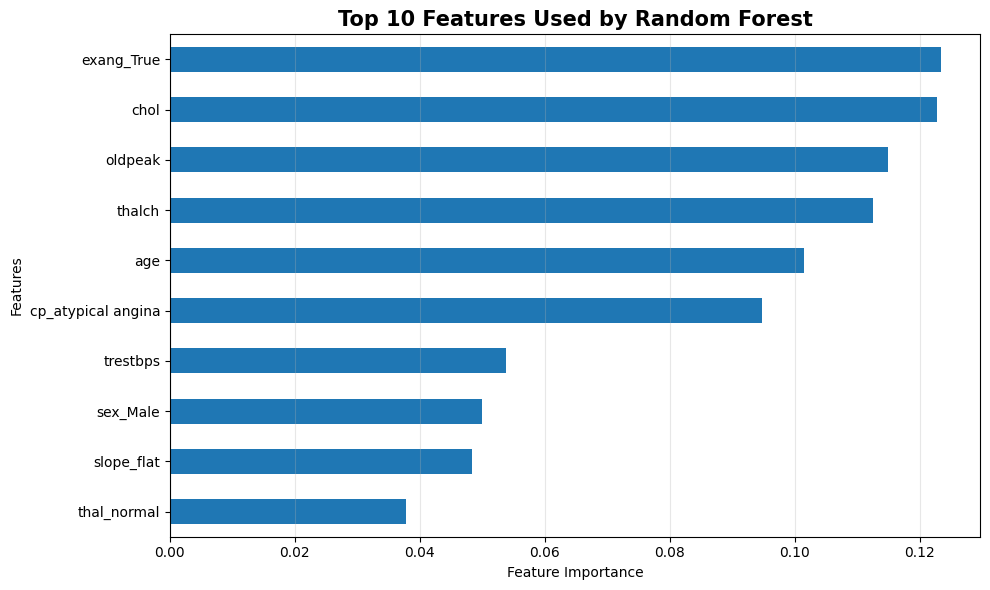

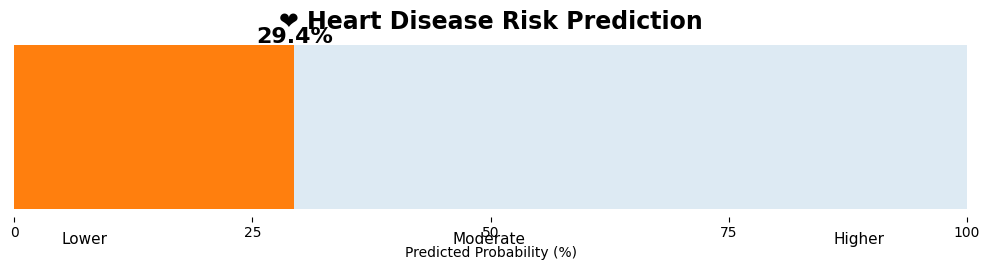


                 🩺 PREDICTION RESULT

Predicted Probability: 29.39%
Risk Category: LOWER PREDICTED RISK

⚠️ Educational model only.
This prediction is not a medical diagnosis.
A qualified healthcare professional should make clinical decisions.

                 📈 MODEL COMPARISON


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.8370,0.8333,0.8824
1,Decision Tree,0.7935,0.8077,0.8235
2,Random Forest,0.8478,0.8558,0.8725


In [14]:
# ============================================================
# ❤️ EXTRA FEATURE: HEART DISEASE RISK PREDICTOR
# Random Forest + Risk Probability + Visual Risk Meter
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 65)
print("        ❤️ HEART DISEASE RISK PREDICTION MODEL")
print("=" * 65)

# ------------------------------------------------------------
# 1. Train Random Forest Model
# ------------------------------------------------------------

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    class_weight='balanced'
)

random_forest.fit(X_train, y_train)

# Predictions
rf_pred = random_forest.predict(X_test)
rf_probability = random_forest.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)

print("\n📊 RANDOM FOREST PERFORMANCE")
print("-" * 45)
print(f"Accuracy  : {rf_accuracy:.2%}")
print(f"Precision : {rf_precision:.2%}")
print(f"Recall    : {rf_recall:.2%}")


# ------------------------------------------------------------
# 2. Feature Importance
# ------------------------------------------------------------

importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n🔍 TOP 10 IMPORTANT FEATURES")
print("-" * 45)
print(importance.head(10).round(4))


# ------------------------------------------------------------
# 3. Feature Importance Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(kind='barh')

plt.title(
    "Top 10 Features Used by Random Forest",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Risk Prediction for a Test Patient
# ------------------------------------------------------------

# Select one patient from test dataset
patient = X_test.iloc[[0]]

risk_probability = random_forest.predict_proba(patient)[0][1]
risk_percentage = risk_probability * 100


# ------------------------------------------------------------
# 5. Attractive Risk Meter
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 2.8))

ax.barh(
    0,
    100,
    height=0.35,
    alpha=0.15
)

ax.barh(
    0,
    risk_percentage,
    height=0.35
)

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel("Predicted Probability (%)")

ax.set_title(
    "❤️ Heart Disease Risk Prediction",
    fontsize=17,
    fontweight='bold'
)

ax.text(
    risk_percentage,
    0.18,
    f"{risk_percentage:.1f}%",
    ha='center',
    fontsize=16,
    fontweight='bold'
)

ax.text(
    5,
    -0.25,
    "Lower",
    fontsize=11
)

ax.text(
    46,
    -0.25,
    "Moderate",
    fontsize=11
)

ax.text(
    86,
    -0.25,
    "Higher",
    fontsize=11
)

ax.set_frame_on(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Prediction Result
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("                 🩺 PREDICTION RESULT")
print("=" * 65)

print(f"\nPredicted Probability: {risk_percentage:.2f}%")

if risk_percentage < 30:
    risk_level = "LOWER PREDICTED RISK"
elif risk_percentage < 60:
    risk_level = "MODERATE PREDICTED RISK"
else:
    risk_level = "HIGHER PREDICTED RISK"

print(f"Risk Category: {risk_level}")

print("\n⚠️ Educational model only.")
print("This prediction is not a medical diagnosis.")
print("A qualified healthcare professional should make clinical decisions.")


# ------------------------------------------------------------
# 7. Final Model Comparison
# ------------------------------------------------------------

comparison_extra = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        rf_accuracy
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        rf_precision
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        rf_recall
    ]
})

print("\n" + "=" * 65)
print("                 📈 MODEL COMPARISON")
print("=" * 65)

display(comparison_extra.round(4))